# Phân cụm sinh viên bằng K-mean

Notebook này dùng file Excel điểm hệ số 4 của lớp để phân cụm sinh viên thành 3 nhóm bằng thuật toán **K-means**.

Bản code này đã sửa:

- Không gán điểm ảo cho sinh viên không có điểm.
- Sinh viên không đủ dữ liệu được đưa vào nhóm riêng: **Không đủ dữ liệu để phân cụm**.
- Điểm trung bình trong Excel làm tròn **2 số sau dấu phẩy**.
- File Excel đầu ra được sắp xếp theo cụm, tô màu theo cụm, đóng băng dòng tiêu đề và căn chỉnh đẹp hơn.


## Lưu ý đã sửa lỗi đếm số môn có điểm

File Excel đầu vào có một số ô điểm bị Excel tự động hiểu thành **ngày tháng**. Ví dụ điểm `3.5` có thể bị lưu thành ngày `03/05/2026`. Vì vậy phiên bản này đã bổ sung hàm xử lý để chuyển ngược ngày tháng về điểm hệ số 4 trước khi đếm số môn có điểm và phân cụm.


## 1. Import thư viện

Nếu máy chưa có thư viện, chạy lệnh sau trong Terminal:

```bash
pip install pandas openpyxl scikit-learn matplotlib
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter


## 2. Cấu hình file

Đặt file điểm Excel cùng thư mục với notebook và đổi tên thành `input.xlsx`.


In [2]:
INPUT_FILE = "input.xlsx"
OUTPUT_FILE = "ket_qua_phan_cum_kmeans_sua_dem_mon.xlsx"

K = 3

# Điều kiện để sinh viên được đưa vào K-means
# Sinh viên phải có dữ liệu ở đủ 3 nhóm môn và có ít nhất 5 môn có điểm.
MIN_SO_NHOM_CO_DU_LIEU = 3
MIN_SO_MON_CO_DIEM = 5


## 3. Đọc file Excel gốc

In [3]:
df_raw = pd.read_excel(INPUT_FILE, header=None)

print("Kích thước file gốc:", df_raw.shape)
df_raw.head(10)


Kích thước file gốc: (56, 74)


,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,TỔNG HỢP ĐIỂM\n(Từ kỳ 1 năm nhất - hết kỳ 2 nă...,NaN,STT,1,2,3,4,5,6,7,...,62,63,64,65,66,67,68,69,70,71
1,NaN,NaN,MSSV,K225480106002,K225480106095,K225510201001,K225480106082,K225480106001,K225480106100,K225480106008,...,K225480106062,K225480106064,K225480106065,K225480106069,K225480106070,K225480106067,K225480106068,K225480106075,K225480106074,K225480106073
2,NaN,NaN,Tên Sinh Viên,Nguyễn Tuấn Anh,Nguyễn Tuấn Anh,Bùi Ngọc Anh,Vũ Việt Anh,Lê Tuấn Anh,Lý Văn Cường,Nguyễn Khánh Duy,...,Nguyễn Văn Thứ,Hoàng Thị Xuân Trang,Lê Quốc Trung,Lê Ngọc Tú,Nguyễn Đức Anh Tú,Nguyễn Đình Tú,Vũ Đức Tú,Nguyễn Đức Việt,Nguyễn Hoàng Việt,Lương Hoàng Việt
3,STT,Mã Môn học,Tên Môn học,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,TEE0432,Kỹ thuật lập trình nâng cao,2026-05-02 00:00:00,3,3.0,3,3,3,3,...,3.7,3,3,NaN,3,3,3,3,3,3.7
5,2,TEE0591,Trí tuệ nhân tạo và học máy,2026-05-03 00:00:00,2,2026-05-02 00:00:00,3,3,3,3.7,...,3.5,3.5,3,NaN,3,3.5,3,3,3.7,3.7
6,3,TEE321,Xử lý ảnh,1.0,1,3.0,2.5,2,3.5,1,...,3,3,1,NaN,3,3,1,3,3,3.5
7,4,WSH442,Thực tập chuyên ngành Công nghệ phần mềm,3.0,3,2.0,NaN,3,4,3,...,3.5,3,1,NaN,2.5,3.5,4,2,3.7,3.7
8,5,TEE0480,Công nghệ phần mềm,2026-05-03 00:00:00,NaN,2026-05-02 00:00:00,3,3,3.5,2,...,3,3.5,1,NaN,3,3,3,3,3,3
9,6,TEE0497,Quản lý dự án công nghệ thông tin,2026-05-03 00:00:00,3,3.0,3.5,3.5,3.7,3,...,3.7,3,3.5,NaN,3.5,3.5,3.5,3,3.5,3.7


## 4. Tự nhận diện vị trí MSSV, tên sinh viên và danh sách môn học

In [4]:
def find_row_contains(df, keywords, max_rows=15):
    """Tìm dòng có chứa một trong các từ khóa."""
    keywords = [k.lower() for k in keywords]
    for i in range(min(max_rows, len(df))):
        row_text = " ".join(df.iloc[i].astype(str).str.lower().tolist())
        if any(k in row_text for k in keywords):
            return i
    return None


def find_col_contains(df, keywords, max_rows=20):
    """Tìm cột có chứa một trong các từ khóa trong vài dòng đầu."""
    keywords = [k.lower() for k in keywords]
    for j in range(df.shape[1]):
        col_text = " ".join(df.iloc[:max_rows, j].astype(str).str.lower().tolist())
        if any(k in col_text for k in keywords):
            return j
    return None

mssv_row = find_row_contains(df_raw, ["mssv", "mã sv", "ma sv"])
name_row = find_row_contains(df_raw, ["tên sinh viên", "ten sinh vien", "họ tên", "ho ten"])
subject_name_col = find_col_contains(df_raw, ["tên hp", "tên học phần", "ten hp", "ten hoc phan"])
subject_code_col = find_col_contains(df_raw, ["mã hp", "ma hp", "mã học phần", "ma hoc phan"])

if mssv_row is None:
    mssv_row = 1
if name_row is None:
    name_row = mssv_row + 1
if subject_name_col is None:
    subject_name_col = 2
if subject_code_col is None:
    subject_code_col = 1

subject_start_row = name_row + 1
while subject_start_row < len(df_raw):
    value = df_raw.iloc[subject_start_row, subject_name_col]
    if pd.notna(value) and str(value).strip().lower() not in ["nan", "", "tên hp", "tên học phần"]:
        break
    subject_start_row += 1

print("Dòng MSSV:", mssv_row)
print("Dòng tên sinh viên:", name_row)
print("Cột mã học phần:", subject_code_col)
print("Cột tên học phần:", subject_name_col)
print("Dòng bắt đầu danh sách môn:", subject_start_row)


Dòng MSSV: 1
Dòng tên sinh viên: 2
Cột mã học phần: 1
Cột tên học phần: 2
Dòng bắt đầu danh sách môn: 3


## 5. Chuyển dữ liệu về dạng bảng sinh viên

In [5]:
student_columns = []
for col in df_raw.columns:
    mssv = df_raw.iloc[mssv_row, col]
    ho_ten = df_raw.iloc[name_row, col]
    if pd.notna(mssv) and pd.notna(ho_ten):
        mssv_str = str(mssv).strip()
        name_str = str(ho_ten).strip()
        if mssv_str.lower() not in ["mssv", "nan", ""] and name_str.lower() not in ["tên sinh viên", "ten sinh vien", "nan", ""]:
            student_columns.append(col)

students = []
subject_names = df_raw.iloc[subject_start_row:, subject_name_col].reset_index(drop=True)

for col in student_columns:
    mssv = str(df_raw.iloc[mssv_row, col]).strip()
    ho_ten = str(df_raw.iloc[name_row, col]).strip()
    scores = df_raw.iloc[subject_start_row:, col].reset_index(drop=True)

    student_data = {"MSSV": mssv, "Họ tên": ho_ten}

    for subject, score in zip(subject_names, scores):
        if pd.notna(subject):
            subject = str(subject).strip()
            if subject and subject.lower() != "nan":
                student_data[subject] = score

    students.append(student_data)

df = pd.DataFrame(students)
info_cols = ["MSSV", "Họ tên"]
subject_cols = [c for c in df.columns if c not in info_cols]

print("Số sinh viên đọc được:", df.shape[0])
print("Số môn học đọc được:", len(subject_cols))
df.head()


Số sinh viên đọc được: 71
Số môn học đọc được: 53


,MSSV,Họ tên,Tên Môn học,Kỹ thuật lập trình nâng cao,Trí tuệ nhân tạo và học máy,Xử lý ảnh,Thực tập chuyên ngành Công nghệ phần mềm,Công nghệ phần mềm,Quản lý dự án công nghệ thông tin,An toàn và bảo mật thông tin,...,Bóng rổ 1,Đại số tuyến tính,Vật lý 1,Kinh tế chính trị Mác - Lênin,Tiếng Anh 2,Quản lý chất lượng,Nhập môn về KT máy tính,Giáo dục thể chất bắt buộc,Triết học Mác - Lênin,Tiếng Anh 1
0,K225480106002,Nguyễn Tuấn Anh,NaN,2026-05-02 00:00:00,2026-05-03 00:00:00,1.0,3.0,2026-05-03 00:00:00,2026-05-03 00:00:00,2026-07-03 00:00:00,...,2.0,2.0,2026-05-01 00:00:00,3.0,2.0,1.0,2026-05-02 00:00:00,2026-05-02 00:00:00,3.0,3.0
1,K225480106095,Nguyễn Tuấn Anh,NaN,3,2,1,3,NaN,3,3.7,...,2,1.5,1.5,1,3,2,2,1.5,3,1
2,K225510201001,Bùi Ngọc Anh,NaN,3.0,2026-05-02 00:00:00,3.0,2.0,2026-05-02 00:00:00,3.0,2.0,...,NaN,3.0,NaN,2026-05-01 00:00:00,2.0,NaN,NaN,NaN,1.0,3.0
3,K225480106082,Vũ Việt Anh,NaN,3,3,2.5,NaN,3,3.5,3.7,...,NaN,1,1,2.5,1,NaN,3,1,2,1
4,K225480106001,Lê Tuấn Anh,NaN,3,3,2,3,3,3.5,3.7,...,3,3,2,1,2.5,1,2,2.5,1,1


## 6. Làm sạch điểm hệ số 4

Chỉ giữ điểm hợp lệ từ 0 đến 4. Ô trống, chữ, ngày tháng hoặc giá trị ngoài khoảng sẽ chuyển thành `NaN`.


In [6]:
from datetime import datetime, date

def clean_score(value):
    """
    Chuyển điểm về dạng số hợp lệ từ 0 đến 4.

    Lưu ý: Trong file Excel, một số điểm như 3.5 hoặc 3.7 có thể bị Excel hiểu nhầm
    thành kiểu ngày tháng, ví dụ 03/05/2026 hoặc 03/07/2026.
    Khi đó ta chuyển ngược lại:
        ngày 03/05 -> 3.5
        ngày 03/07 -> 3.7
        ngày 02/05 -> 2.5
    """
    if pd.isna(value):
        return np.nan

    # Trường hợp Excel tự đổi điểm thành ngày tháng
    if isinstance(value, (datetime, date)):
        diem = value.day + value.month / 10
        if 0 <= diem <= 4:
            return diem
        return np.nan

    # Trường hợp điểm là số hoặc chuỗi số
    try:
        text = str(value).strip().replace(",", ".")
        x = float(text)
    except Exception:
        return np.nan

    if 0 <= x <= 4:
        return x
    return np.nan


for col in subject_cols:
    df[col] = df[col].apply(clean_score)

# Số môn có điểm được tính sau khi đã sửa cả lỗi điểm bị Excel đổi thành ngày tháng
df["Số_môn_có_điểm"] = df[subject_cols].notna().sum(axis=1)

df[["MSSV", "Họ tên", "Số_môn_có_điểm"]].head()


,MSSV,Họ tên,Số_môn_có_điểm
0,K225480106002,Nguyễn Tuấn Anh,50
1,K225480106095,Nguyễn Tuấn Anh,47
2,K225510201001,Bùi Ngọc Anh,38
3,K225480106082,Vũ Việt Anh,47
4,K225480106001,Lê Tuấn Anh,49


## 7. Chia môn học thành 3 nhóm năng lực

In [7]:
nhom_phan_mem = [
    "Kỹ thuật lập trình nâng cao",
    "Thực tập chuyên ngành Công nghệ phần mềm",
    "Công nghệ phần mềm",
    "Quản lý dự án công nghệ thông tin",
    "Quản lý dự án CNTT",
    "Phát triển ứng dụng trên nền web",
    "Lập trình Python",
    "Hệ quản trị cơ sở dữ liệu",
    "Đồ án phân tích thiết kế hệ thống",
    "Phân tích và thiết kế hệ thống",
    "Lập trình hướng đối tượng",
    "Cơ sở dữ liệu",
    "Quản lý chất lượng"
]

nhom_ai_du_lieu = [
    "Trí tuệ nhân tạo và học máy",
    "Xử lý ảnh",
    "Cấu trúc dữ liệu và giải thuật",
    "Xác suất thống kê",
    "Xử lý tín hiệu số",
    "Toán rời rạc",
    "Đại số tuyến tính",
    "Giải tích 2",
    "Toán 2(Giải tích 1)",
    "Toán 2 (Giải tích 1)"
]

nhom_he_thong_mang_nhung = [
    "An toàn và bảo mật thông tin",
    "Quản trị mạng",
    "Đồ án mạng máy tính",
    "Thiết bị truyền thông và mạng máy tính",
    "Hệ điều hành",
    "Mạng máy tính",
    "Đồ án hệ thống nhúng",
    "Kiến trúc máy tính",
    "Thiết kế logic số",
    "Hệ thống nhúng",
    "Vi xử lý – Vi điều khiển",
    "Vi xử lý - Vi điều khiển",
    "Nhập môn về KT máy tính"
]


def lay_mon_co_trong_file(ds_mon, df_columns):
    normalized_map = {str(c).strip().lower(): c for c in df_columns}
    result = []
    for mon in ds_mon:
        key = str(mon).strip().lower()
        if key in normalized_map and normalized_map[key] not in result:
            result.append(normalized_map[key])
    return result

mon_phan_mem = lay_mon_co_trong_file(nhom_phan_mem, df.columns)
mon_ai_du_lieu = lay_mon_co_trong_file(nhom_ai_du_lieu, df.columns)
mon_he_thong = lay_mon_co_trong_file(nhom_he_thong_mang_nhung, df.columns)

print("Môn nhóm Phát triển phần mềm:", len(mon_phan_mem))
print(mon_phan_mem)
print("\nMôn nhóm AI - Dữ liệu - Thuật toán:", len(mon_ai_du_lieu))
print(mon_ai_du_lieu)
print("\nMôn nhóm Hệ thống - Mạng - Nhúng:", len(mon_he_thong))
print(mon_he_thong)


Môn nhóm Phát triển phần mềm: 12
['Kỹ thuật lập trình nâng cao', 'Thực tập chuyên ngành Công nghệ phần mềm', 'Công nghệ phần mềm', 'Quản lý dự án công nghệ thông tin', 'Phát triển ứng dụng trên nền web', 'Lập trình Python', 'Hệ quản trị cơ sở dữ liệu', 'Đồ án phân tích thiết kế hệ thống', 'Phân tích và thiết kế hệ thống', 'Lập trình hướng đối tượng', 'Cơ sở dữ liệu', 'Quản lý chất lượng']

Môn nhóm AI - Dữ liệu - Thuật toán: 9
['Trí tuệ nhân tạo và học máy', 'Xử lý ảnh', 'Cấu trúc dữ liệu và giải thuật', 'Xác suất thống kê', 'Xử lý tín hiệu số', 'Toán rời rạc', 'Đại số tuyến tính', 'Giải tích 2', 'Toán 2(Giải tích 1)']

Môn nhóm Hệ thống - Mạng - Nhúng: 12
['An toàn và bảo mật thông tin', 'Quản trị mạng', 'Đồ án mạng máy tính', 'Thiết bị truyền thông và mạng máy tính', 'Hệ điều hành', 'Mạng máy tính', 'Đồ án hệ thống nhúng', 'Kiến trúc máy tính', 'Thiết kế logic số', 'Hệ thống nhúng', 'Vi xử lý – Vi điều khiển', 'Nhập môn về KT máy tính']


## 8. Tính điểm trung bình theo 3 nhóm môn

Không tự điền điểm trống bằng điểm trung bình của lớp.


In [8]:
df_features = df[["MSSV", "Họ tên", "Số_môn_có_điểm"]].copy()

df_features["TB_Phát_triển_phần_mềm"] = df[mon_phan_mem].mean(axis=1) if mon_phan_mem else np.nan
df_features["TB_AI_Dữ_liệu_Thuật_toán"] = df[mon_ai_du_lieu].mean(axis=1) if mon_ai_du_lieu else np.nan
df_features["TB_Hệ_thống_Mạng_Nhúng"] = df[mon_he_thong].mean(axis=1) if mon_he_thong else np.nan

feature_cols = [
    "TB_Phát_triển_phần_mềm",
    "TB_AI_Dữ_liệu_Thuật_toán",
    "TB_Hệ_thống_Mạng_Nhúng"
]

df_features["Số_nhóm_có_dữ_liệu"] = df_features[feature_cols].notna().sum(axis=1)

df_features["Đủ_dữ_liệu"] = (
    (df_features["Số_nhóm_có_dữ_liệu"] >= MIN_SO_NHOM_CO_DU_LIEU) &
    (df_features["Số_môn_có_điểm"] >= MIN_SO_MON_CO_DIEM)
)

df_features.head()


,MSSV,Họ tên,Số_môn_có_điểm,TB_Phát_triển_phần_mềm,TB_AI_Dữ_liệu_Thuật_toán,TB_Hệ_thống_Mạng_Nhúng,Số_nhóm_có_dữ_liệu,Đủ_dữ_liệu
0,K225480106002,Nguyễn Tuấn Anh,50,2.958333,2.000000,2.609091,3,True
1,K225480106095,Nguyễn Tuấn Anh,47,2.990909,1.562500,2.391667,3,True
2,K225510201001,Bùi Ngọc Anh,38,2.545455,2.375000,1.875000,3,True
3,K225480106082,Vũ Việt Anh,47,2.900000,1.944444,2.245455,3,True
4,K225480106001,Lê Tuấn Anh,49,2.950000,2.300000,2.336364,3,True


## 9. Chạy K-means với K = 3

In [9]:
df_cluster = df_features[df_features["Đủ_dữ_liệu"]].copy()

if len(df_cluster) < K:
    raise ValueError("Không đủ sinh viên có dữ liệu hợp lệ để phân cụm K-means.")

X = df_cluster[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(X_scaled)

df_cluster["Nhan_cum_goc"] = raw_labels

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
df_centers = pd.DataFrame(centers_original, columns=feature_cols)
df_centers["Nhan_cum_goc"] = df_centers.index
df_centers["Điểm_TB_chung"] = df_centers[feature_cols].mean(axis=1)

# Sắp xếp lại mã cụm: cụm 1 điểm cao nhất, cụm 2 trung bình, cụm 3 thấp hơn.
rank_order = df_centers.sort_values("Điểm_TB_chung", ascending=False)["Nhan_cum_goc"].tolist()
label_to_ma_cum = {old_label: rank + 1 for rank, old_label in enumerate(rank_order)}

ten_cum_mapping = {
    1: "Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn mạnh",
    2: "Cụm 2 - Nhóm học lực khá, năng lực tương đối cân bằng",
    3: "Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuyên môn"
}

df_cluster["Mã cụm"] = df_cluster["Nhan_cum_goc"].map(label_to_ma_cum)
df_cluster["Tên cụm"] = df_cluster["Mã cụm"].map(ten_cum_mapping)

df_centers["Mã cụm"] = df_centers["Nhan_cum_goc"].map(label_to_ma_cum)
df_centers["Tên cụm"] = df_centers["Mã cụm"].map(ten_cum_mapping)
df_centers = df_centers.sort_values("Mã cụm").reset_index(drop=True)

df_cluster.head()


,MSSV,Họ tên,Số_môn_có_điểm,TB_Phát_triển_phần_mềm,TB_AI_Dữ_liệu_Thuật_toán,TB_Hệ_thống_Mạng_Nhúng,Số_nhóm_có_dữ_liệu,Đủ_dữ_liệu,Nhan_cum_goc,Mã cụm,Tên cụm
0,K225480106002,Nguyễn Tuấn Anh,50,2.958333,2.000000,2.609091,3,True,0,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...
1,K225480106095,Nguyễn Tuấn Anh,47,2.990909,1.562500,2.391667,3,True,0,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...
2,K225510201001,Bùi Ngọc Anh,38,2.545455,2.375000,1.875000,3,True,0,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...
3,K225480106082,Vũ Việt Anh,47,2.900000,1.944444,2.245455,3,True,0,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...
4,K225480106001,Lê Tuấn Anh,49,2.950000,2.300000,2.336364,3,True,0,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...


## 10. Gán nhãn cụm và xác định nhóm mạnh nhất

In [10]:
def nhom_manh_nhat(row):
    values = {
        "Phát triển phần mềm": row["TB_Phát_triển_phần_mềm"],
        "AI - Dữ liệu - Thuật toán": row["TB_AI_Dữ_liệu_Thuật_toán"],
        "Hệ thống - Mạng - Nhúng": row["TB_Hệ_thống_Mạng_Nhúng"]
    }
    values = {k: v for k, v in values.items() if pd.notna(v)}
    if not values:
        return "Không đủ dữ liệu"
    return max(values, key=values.get)

df_features["Mã cụm"] = np.nan
df_features["Tên cụm"] = "Không đủ dữ liệu để phân cụm"
df_features["Nhóm_mạnh_nhất"] = df_features.apply(nhom_manh_nhat, axis=1)

for idx, row in df_cluster.iterrows():
    df_features.loc[idx, "Mã cụm"] = row["Mã cụm"]
    df_features.loc[idx, "Tên cụm"] = row["Tên cụm"]

df_features["Mã cụm"] = df_features["Mã cụm"].astype("Int64")
df_features.head()


,MSSV,Họ tên,Số_môn_có_điểm,TB_Phát_triển_phần_mềm,TB_AI_Dữ_liệu_Thuật_toán,TB_Hệ_thống_Mạng_Nhúng,Số_nhóm_có_dữ_liệu,Đủ_dữ_liệu,Mã cụm,Tên cụm,Nhóm_mạnh_nhất
0,K225480106002,Nguyễn Tuấn Anh,50,2.958333,2.000000,2.609091,3,True,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,Phát triển phần mềm
1,K225480106095,Nguyễn Tuấn Anh,47,2.990909,1.562500,2.391667,3,True,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,Phát triển phần mềm
2,K225510201001,Bùi Ngọc Anh,38,2.545455,2.375000,1.875000,3,True,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,Phát triển phần mềm
3,K225480106082,Vũ Việt Anh,47,2.900000,1.944444,2.245455,3,True,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,Phát triển phần mềm
4,K225480106001,Lê Tuấn Anh,49,2.950000,2.300000,2.336364,3,True,3,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,Phát triển phần mềm


## 11. Sắp xếp kết quả cho dễ nhìn

In [11]:
def sort_order(row):
    if pd.isna(row["Mã cụm"]):
        return 99
    return int(row["Mã cụm"])

cols_output = [
    "MSSV",
    "Họ tên",
    "TB_Phát_triển_phần_mềm",
    "TB_AI_Dữ_liệu_Thuật_toán",
    "TB_Hệ_thống_Mạng_Nhúng",
    "Số_môn_có_điểm",
    "Số_nhóm_có_dữ_liệu",
    "Mã cụm",
    "Tên cụm",
    "Nhóm_mạnh_nhất"
]

df_result = df_features[cols_output].copy()
df_result["Thu_tu_sap_xep"] = df_result.apply(sort_order, axis=1)
df_result = df_result.sort_values(["Thu_tu_sap_xep", "Họ tên"]).drop(columns=["Thu_tu_sap_xep"]).reset_index(drop=True)

df_result_display = df_result.copy()
df_result_display[feature_cols] = df_result_display[feature_cols].round(2)

df_result_display.head(20)


,MSSV,Họ tên,TB_Phát_triển_phần_mềm,TB_AI_Dữ_liệu_Thuật_toán,TB_Hệ_thống_Mạng_Nhúng,Số_môn_có_điểm,Số_nhóm_có_dữ_liệu,Mã cụm,Tên cụm,Nhóm_mạnh_nhất
0,K225480106045,Dương Thị Ly,3.19,3.24,3.28,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Hệ thống - Mạng - Nhúng
1,K225480106053,Hoàng Kim Ngọc,3.58,3.53,3.45,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
2,K225480106056,Hoàng Thị Quyến,3.58,3.34,3.16,46,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
3,K225480106016,Hứa Thị Thanh Hiền,3.40,3.38,3.18,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
4,K225480106025,Lương Văn Học,3.18,3.10,3.02,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
5,K225480106013,Lường Văn Hạnh,3.88,3.29,3.41,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
6,K225480106030,Nguyễn Như Khiêm,3.37,3.24,3.38,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Hệ thống - Mạng - Nhúng
7,K225480106026,Nguyễn Thị Kim Huệ,3.08,3.41,3.02,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",AI - Dữ liệu - Thuật toán
8,K225480106058,Nguyễn Tiến Thắng,3.43,3.37,3.18,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
9,K225480106019,Nguyễn Trung Hiếu,3.55,3.29,3.09,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm


## 12. Thống kê số lượng sinh viên theo cụm

In [12]:
thong_ke_cum = df_result.groupby(["Tên cụm"], dropna=False).size().reset_index(name="Số lượng sinh viên")

def order_ten_cum(ten):
    ten = str(ten)
    if ten.startswith("Cụm 1"):
        return 1
    if ten.startswith("Cụm 2"):
        return 2
    if ten.startswith("Cụm 3"):
        return 3
    return 99

thong_ke_cum["Thứ tự"] = thong_ke_cum["Tên cụm"].apply(order_ten_cum)
thong_ke_cum = thong_ke_cum.sort_values("Thứ tự").drop(columns=["Thứ tự"]).reset_index(drop=True)
thong_ke_cum["Tỷ lệ"] = thong_ke_cum["Số lượng sinh viên"] / len(df_result)

thong_ke_cum


,Tên cụm,Số lượng sinh viên,Tỷ lệ
0,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",14,0.197183
1,"Cụm 2 - Nhóm học lực khá, năng lực tương đối c...",23,0.323944
2,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,23,0.323944
3,Không đủ dữ liệu để phân cụm,11,0.154930


## 13. Vẽ biểu đồ số lượng sinh viên theo cụm

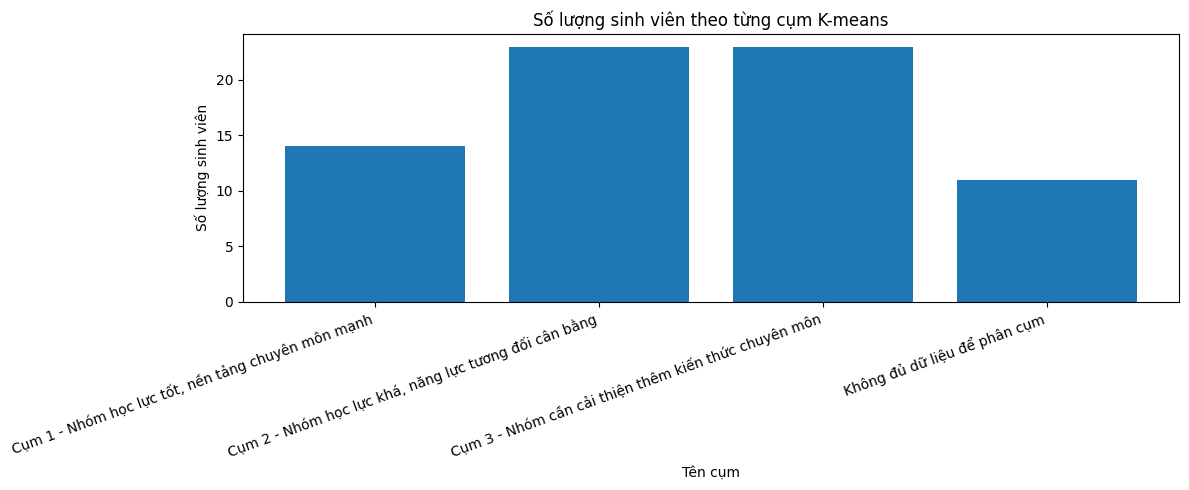

In [13]:
plt.figure(figsize=(12, 5))
plt.bar(thong_ke_cum["Tên cụm"], thong_ke_cum["Số lượng sinh viên"])
plt.xlabel("Tên cụm")
plt.ylabel("Số lượng sinh viên")
plt.title("Số lượng sinh viên theo từng cụm K-means")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 14. Vẽ biểu đồ tâm cụm

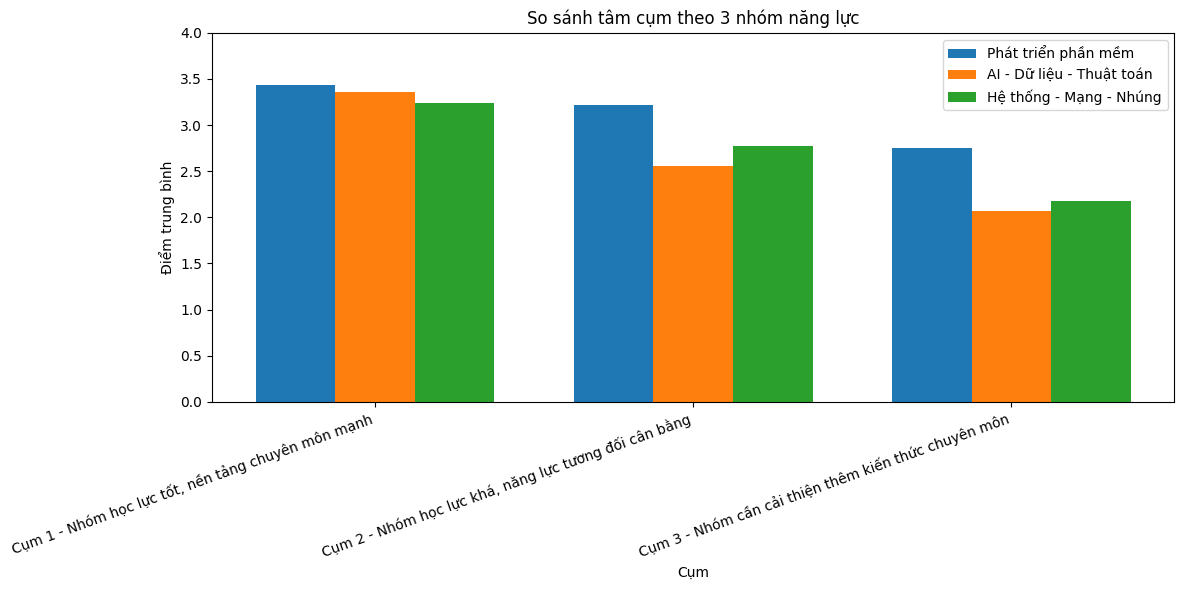

In [14]:
df_centers_plot = df_centers.copy()

plt.figure(figsize=(12, 6))
x = np.arange(len(df_centers_plot["Tên cụm"]))
width = 0.25

plt.bar(x - width, df_centers_plot["TB_Phát_triển_phần_mềm"], width, label="Phát triển phần mềm")
plt.bar(x, df_centers_plot["TB_AI_Dữ_liệu_Thuật_toán"], width, label="AI - Dữ liệu - Thuật toán")
plt.bar(x + width, df_centers_plot["TB_Hệ_thống_Mạng_Nhúng"], width, label="Hệ thống - Mạng - Nhúng")

plt.xlabel("Cụm")
plt.ylabel("Điểm trung bình")
plt.title("So sánh tâm cụm theo 3 nhóm năng lực")
plt.xticks(x, df_centers_plot["Tên cụm"], rotation=20, ha="right")
plt.ylim(0, 4)
plt.legend()
plt.tight_layout()
plt.show()


## 15. Vẽ phân cụm 2D bằng PCA

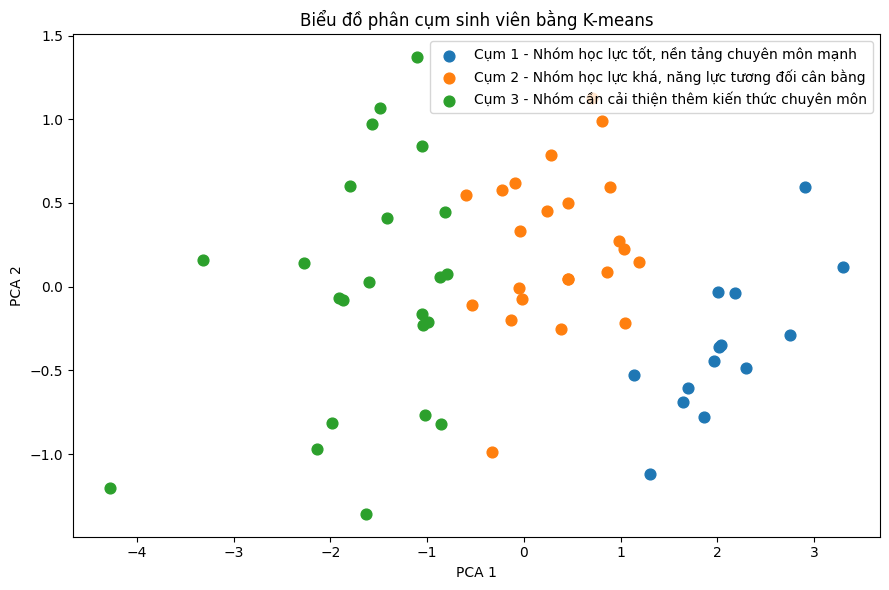

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_cluster_plot = df_cluster.copy()
df_cluster_plot["PCA1"] = X_pca[:, 0]
df_cluster_plot["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(9, 6))

for ma_cum in sorted(df_cluster_plot["Mã cụm"].unique()):
    data_cum = df_cluster_plot[df_cluster_plot["Mã cụm"] == ma_cum]
    plt.scatter(data_cum["PCA1"], data_cum["PCA2"], label=ten_cum_mapping[ma_cum], s=60)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Biểu đồ phân cụm sinh viên bằng K-means")
plt.legend()
plt.tight_layout()
plt.show()


## 16. Xuất file Excel

In [16]:
df_export = df_result.copy()
for col in feature_cols:
    df_export[col] = df_export[col].round(2)

df_centers_export = df_centers[[
    "Mã cụm",
    "Tên cụm",
    "TB_Phát_triển_phần_mềm",
    "TB_AI_Dữ_liệu_Thuật_toán",
    "TB_Hệ_thống_Mạng_Nhúng",
    "Điểm_TB_chung"
]].copy()
for col in feature_cols + ["Điểm_TB_chung"]:
    df_centers_export[col] = df_centers_export[col].round(2)

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    df_export.to_excel(writer, sheet_name="Ket_qua_phan_cum", index=False)
    df_centers_export.to_excel(writer, sheet_name="Tam_cum", index=False)
    thong_ke_cum.to_excel(writer, sheet_name="Thong_ke_cum", index=False)
    pd.DataFrame({"Môn nhóm Phát triển phần mềm": mon_phan_mem}).to_excel(writer, sheet_name="Mon_phan_mem", index=False)
    pd.DataFrame({"Môn nhóm AI - Dữ liệu": mon_ai_du_lieu}).to_excel(writer, sheet_name="Mon_AI_du_lieu", index=False)
    pd.DataFrame({"Môn nhóm Hệ thống - Mạng - Nhúng": mon_he_thong}).to_excel(writer, sheet_name="Mon_he_thong", index=False)

print("Đã xuất dữ liệu sang:", OUTPUT_FILE)


Đã xuất dữ liệu sang: ket_qua_phan_cum_kmeans_sua_dem_mon.xlsx


## 17. Định dạng đẹp file Excel

Cell này làm tròn hiển thị 2 số sau dấu phẩy, tô màu theo 3 cụm, sắp xếp và căn chỉnh bảng cho dễ nhìn.


In [17]:
wb = load_workbook(OUTPUT_FILE)

header_fill = PatternFill("solid", fgColor="1F4E78")
header_font = Font(color="FFFFFF", bold=True)
thin_border = Border(
    left=Side(style="thin", color="D9E2F3"),
    right=Side(style="thin", color="D9E2F3"),
    top=Side(style="thin", color="D9E2F3"),
    bottom=Side(style="thin", color="D9E2F3")
)

cluster_fills = {
    1: PatternFill("solid", fgColor="D9EAD3"),  # xanh lá nhạt
    2: PatternFill("solid", fgColor="DDEBF7"),  # xanh dương nhạt
    3: PatternFill("solid", fgColor="FCE4D6"),  # cam nhạt
    "missing": PatternFill("solid", fgColor="E7E6E6")  # xám nhạt
}

score_columns = [
    "TB_Phát_triển_phần_mềm",
    "TB_AI_Dữ_liệu_Thuật_toán",
    "TB_Hệ_thống_Mạng_Nhúng",
    "Điểm_TB_chung"
]


def format_basic_sheet(ws):
    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = thin_border

    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    for col_idx, column_cells in enumerate(ws.columns, start=1):
        max_length = 0
        col_letter = get_column_letter(col_idx)
        for cell in column_cells:
            if cell.value is not None:
                max_length = max(max_length, len(str(cell.value)))
        ws.column_dimensions[col_letter].width = min(max(max_length + 2, 10), 38)

    ws.row_dimensions[1].height = 30


# Sheet kết quả chính
ws = wb["Ket_qua_phan_cum"]
format_basic_sheet(ws)
headers = {cell.value: cell.column for cell in ws[1]}
ma_cum_col = headers.get("Mã cụm")

for row in ws.iter_rows(min_row=2):
    ma_cum_value = row[ma_cum_col - 1].value if ma_cum_col else None
    fill = cluster_fills.get(ma_cum_value, cluster_fills["missing"])

    for cell in row:
        col_name = ws.cell(row=1, column=cell.column).value
        cell.fill = fill
        if col_name in score_columns:
            cell.number_format = "0.00"
        if col_name in ["Số_môn_có_điểm", "Số_nhóm_có_dữ_liệu", "Mã cụm"]:
            cell.alignment = Alignment(horizontal="center", vertical="center")

# Chỉnh độ rộng một số cột chính
custom_widths = {
    "MSSV": 16,
    "Họ tên": 24,
    "TB_Phát_triển_phần_mềm": 18,
    "TB_AI_Dữ_liệu_Thuật_toán": 20,
    "TB_Hệ_thống_Mạng_Nhúng": 20,
    "Số_môn_có_điểm": 16,
    "Số_nhóm_có_dữ_liệu": 18,
    "Mã cụm": 10,
    "Tên cụm": 52,
    "Nhóm_mạnh_nhất": 30
}
for col_name, width in custom_widths.items():
    if col_name in headers:
        ws.column_dimensions[get_column_letter(headers[col_name])].width = width

# Các sheet còn lại
for sheet_name in wb.sheetnames:
    if sheet_name == "Ket_qua_phan_cum":
        continue
    ws_other = wb[sheet_name]
    format_basic_sheet(ws_other)
    for row in ws_other.iter_rows(min_row=2):
        for cell in row:
            col_name = ws_other.cell(row=1, column=cell.column).value
            if col_name in score_columns:
                cell.number_format = "0.00"
            if col_name == "Tỷ lệ":
                cell.number_format = "0.00%"

# Tô màu sheet tâm cụm
if "Tam_cum" in wb.sheetnames:
    ws_center = wb["Tam_cum"]
    headers_center = {cell.value: cell.column for cell in ws_center[1]}
    ma_col = headers_center.get("Mã cụm")
    if ma_col:
        for row in ws_center.iter_rows(min_row=2):
            ma = row[ma_col - 1].value
            fill = cluster_fills.get(ma, PatternFill("solid", fgColor="FFFFFF"))
            for cell in row:
                cell.fill = fill

# Tô màu sheet thống kê
if "Thong_ke_cum" in wb.sheetnames:
    ws_stat = wb["Thong_ke_cum"]
    for row in ws_stat.iter_rows(min_row=2):
        ten = str(row[0].value)
        if ten.startswith("Cụm 1"):
            fill = cluster_fills[1]
        elif ten.startswith("Cụm 2"):
            fill = cluster_fills[2]
        elif ten.startswith("Cụm 3"):
            fill = cluster_fills[3]
        else:
            fill = cluster_fills["missing"]
        for cell in row:
            cell.fill = fill

wb.save(OUTPUT_FILE)
print("Đã định dạng đẹp file Excel:", OUTPUT_FILE)


Đã định dạng đẹp file Excel: ket_qua_phan_cum_kmeans_sua_dem_mon.xlsx


## 18. Xem nhanh kết quả cuối cùng

In [18]:
print("File kết quả đã tạo:", OUTPUT_FILE)
print("\nThống kê cụm:")
display(thong_ke_cum)

print("\n10 dòng đầu trong kết quả:")
display(df_result_display.head(10))


File kết quả đã tạo: ket_qua_phan_cum_kmeans_sua_dem_mon.xlsx

Thống kê cụm:


,Tên cụm,Số lượng sinh viên,Tỷ lệ
0,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",14,0.197183
1,"Cụm 2 - Nhóm học lực khá, năng lực tương đối c...",23,0.323944
2,Cụm 3 - Nhóm cần cải thiện thêm kiến thức chuy...,23,0.323944
3,Không đủ dữ liệu để phân cụm,11,0.154930



10 dòng đầu trong kết quả:


,MSSV,Họ tên,TB_Phát_triển_phần_mềm,TB_AI_Dữ_liệu_Thuật_toán,TB_Hệ_thống_Mạng_Nhúng,Số_môn_có_điểm,Số_nhóm_có_dữ_liệu,Mã cụm,Tên cụm,Nhóm_mạnh_nhất
0,K225480106045,Dương Thị Ly,3.19,3.24,3.28,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Hệ thống - Mạng - Nhúng
1,K225480106053,Hoàng Kim Ngọc,3.58,3.53,3.45,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
2,K225480106056,Hoàng Thị Quyến,3.58,3.34,3.16,46,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
3,K225480106016,Hứa Thị Thanh Hiền,3.40,3.38,3.18,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
4,K225480106025,Lương Văn Học,3.18,3.10,3.02,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
5,K225480106013,Lường Văn Hạnh,3.88,3.29,3.41,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
6,K225480106030,Nguyễn Như Khiêm,3.37,3.24,3.38,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Hệ thống - Mạng - Nhúng
7,K225480106026,Nguyễn Thị Kim Huệ,3.08,3.41,3.02,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",AI - Dữ liệu - Thuật toán
8,K225480106058,Nguyễn Tiến Thắng,3.43,3.37,3.18,52,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm
9,K225480106019,Nguyễn Trung Hiếu,3.55,3.29,3.09,51,3,1,"Cụm 1 - Nhóm học lực tốt, nền tảng chuyên môn ...",Phát triển phần mềm


## 19. Kết luận mẫu để đưa vào báo cáo

Thuật toán K-means được sử dụng để phân cụm sinh viên dựa trên điểm hệ số 4 của các môn học. Các môn học được chia thành 3 nhóm năng lực chính: Phát triển phần mềm, AI - Dữ liệu - Thuật toán, và Hệ thống - Mạng - Nhúng. Với mỗi sinh viên, chương trình tính điểm trung bình của từng nhóm năng lực, sau đó chuẩn hóa dữ liệu và áp dụng K-means với K = 3.

Những sinh viên không có điểm hoặc không đủ dữ liệu ở 3 nhóm môn học không được đưa vào quá trình huấn luyện K-means, mà được ghi chú là "Không đủ dữ liệu để phân cụm". Cách xử lý này giúp tránh việc gán điểm ảo và bảo đảm kết quả phân cụm phản ánh đúng dữ liệu thật trong file điểm.
